In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.var_model import VAR
import os
os.makedirs('output', exist_ok=True)

TICKERS = ['NVDA', 'MSFT', 'META', 'AMZN', 'GOOGL']

t2 = pd.read_csv('data/table2_price_targets.csv')
t2['Date'] = pd.to_datetime(t2['Date']).dt.normalize()

ret_cc = t2.pivot(index='Date', columns='Ticker', values='ret_total')[TICKERS].dropna()
ret_on = t2.pivot(index='Date', columns='Ticker', values='ret_overnight')[TICKERS].dropna()
ret_id = t2.pivot(index='Date', columns='Ticker', values='ret_intraday')[TICKERS].dropna()

segments = {'close-close': ret_cc, 'overnight': ret_on, 'intraday': ret_id}
for name, mat in segments.items():
    print(f"{name:<12} shape={mat.shape}  per-year={mat.index.year.value_counts().sort_index().to_dict()}")

close-close  shape=(1253, 5)  per-year={2021: 252, 2022: 251, 2023: 250, 2024: 252, 2025: 248}
overnight    shape=(1253, 5)  per-year={2021: 252, 2022: 251, 2023: 250, 2024: 252, 2025: 248}
intraday     shape=(1253, 5)  per-year={2021: 252, 2022: 251, 2023: 250, 2024: 252, 2025: 248}


In [3]:
def sig_cross_stock(fitted, p, alpha_t=1.96):
    names = fitted.names
    k = len(names)
    sig = []
    for L in range(p):
        for to_i in range(k):
            for from_j in range(k):
                if to_i == from_j:
                    continue
                trow = 1 + L * k + from_j
                tval = fitted.tvalues.iloc[trow, to_i]
                if abs(tval) > alpha_t:
                    coef = fitted.coefs[L][to_i][from_j]
                    sig.append((names[from_j], names[to_i], L + 1, coef, tval))
    return sig

In [4]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.simplefilter('ignore', ValueWarning)

print("=" * 60)
print("FULL PERIOD 2021-2025 — cross-stock transmission")
print("=" * 60)

fitted_full = {}
for name, mat in segments.items():
    order = VAR(mat).select_order(maxlags=10)
    p = order.aic if order.aic > 0 else 1
    fitted = VAR(mat).fit(p)
    fitted_full[name] = (fitted, p)
    sig = sig_cross_stock(fitted, p)
    print(f"\n[{name}] AIC p={p}, significant cross-stock coefs = {len(sig)}")
    for frm, to, L, coef, tval in sig:
        print(f"    {frm:>5} -> {to:<6} L{L}  coef={coef:+.4f}  t={tval:+.2f}")

FULL PERIOD 2021-2025 — cross-stock transmission

[close-close] AIC p=1, significant cross-stock coefs = 3
     AMZN -> NVDA   L1  coef=+0.1346  t=+2.16
    GOOGL -> NVDA   L1  coef=-0.1588  t=-2.35
     META -> AMZN   L1  coef=-0.1538  t=-4.99

[overnight] AIC p=2, significant cross-stock coefs = 9
     AMZN -> NVDA   L1  coef=+0.1450  t=+2.83
    GOOGL -> NVDA   L1  coef=-0.1202  t=-2.19
     MSFT -> META   L1  coef=+0.3572  t=+4.85
     META -> AMZN   L1  coef=-0.1783  t=-6.87
    GOOGL -> AMZN   L1  coef=+0.0931  t=+2.29
     META -> GOOGL  L1  coef=-0.0725  t=-3.17
     AMZN -> NVDA   L2  coef=-0.1125  t=-2.23
     AMZN -> MSFT   L2  coef=-0.0538  t=-2.07
    GOOGL -> AMZN   L2  coef=+0.1649  t=+4.02

[intraday] AIC p=1, significant cross-stock coefs = 0


In [5]:
print("=" * 60)
print("YEAR-BY-YEAR — cross-stock transmission (each year own AIC)")
print("=" * 60)

years = [2021, 2022, 2023, 2024, 2025]
yearly_summary = []

for name, mat in segments.items():
    print(f"\n### {name} ###")
    for yr in years:
        data_yr = mat[mat.index.year == yr]
        try:
            order = VAR(data_yr).select_order(maxlags=10)
            p = order.aic
        except Exception:
            p = 0
        if p == 0:
            print(f"  {yr}: AIC p=0  (no lag structure, skipped)")
            yearly_summary.append({'segment': name, 'year': yr, 'p': 0, 'n_sig': 0})
            continue
        fitted = VAR(data_yr).fit(p)
        sig = sig_cross_stock(fitted, p)
        print(f"  {yr}: AIC p={p}, significant cross-stock = {len(sig)}")
        yearly_summary.append({'segment': name, 'year': yr, 'p': p, 'n_sig': len(sig)})

yearly_df = pd.DataFrame(yearly_summary)

YEAR-BY-YEAR — cross-stock transmission (each year own AIC)

### close-close ###
  2021: AIC p=0  (no lag structure, skipped)
  2022: AIC p=2, significant cross-stock = 7
  2023: AIC p=0  (no lag structure, skipped)
  2024: AIC p=0  (no lag structure, skipped)
  2025: AIC p=1, significant cross-stock = 1

### overnight ###
  2021: AIC p=1, significant cross-stock = 1
  2022: AIC p=2, significant cross-stock = 11
  2023: AIC p=1, significant cross-stock = 4
  2024: AIC p=2, significant cross-stock = 22
  2025: AIC p=1, significant cross-stock = 3

### intraday ###
  2021: AIC p=0  (no lag structure, skipped)
  2022: AIC p=0  (no lag structure, skipped)
  2023: AIC p=0  (no lag structure, skipped)
  2024: AIC p=0  (no lag structure, skipped)
  2025: AIC p=1, significant cross-stock = 3


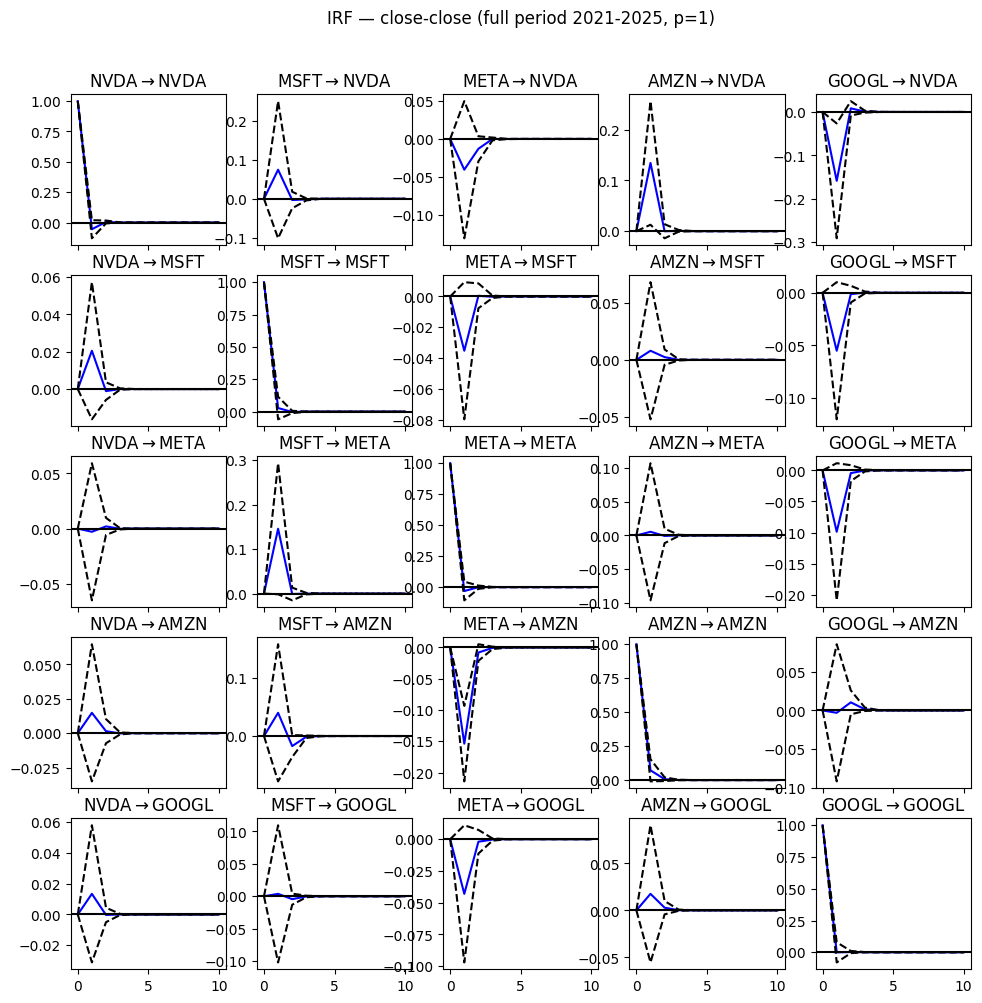

saved: output/irf_fullperiod_close-close.png


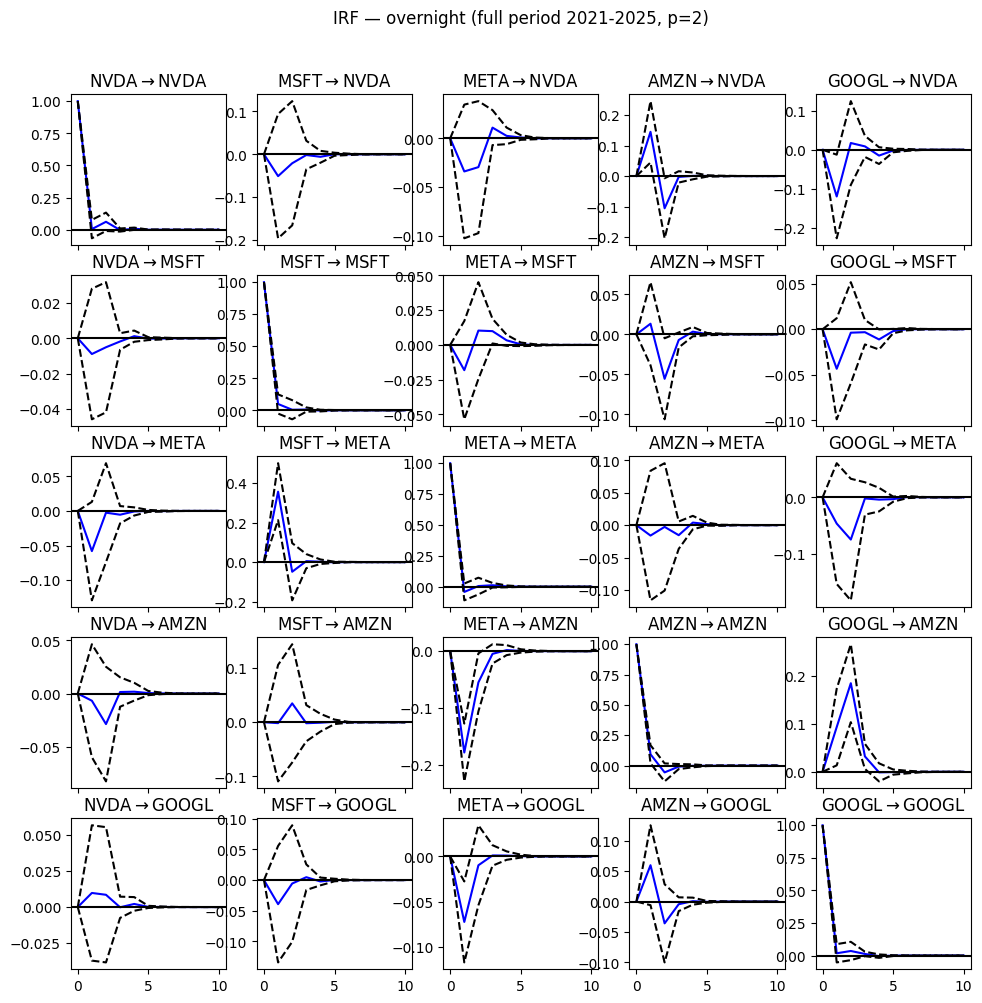

saved: output/irf_fullperiod_overnight.png


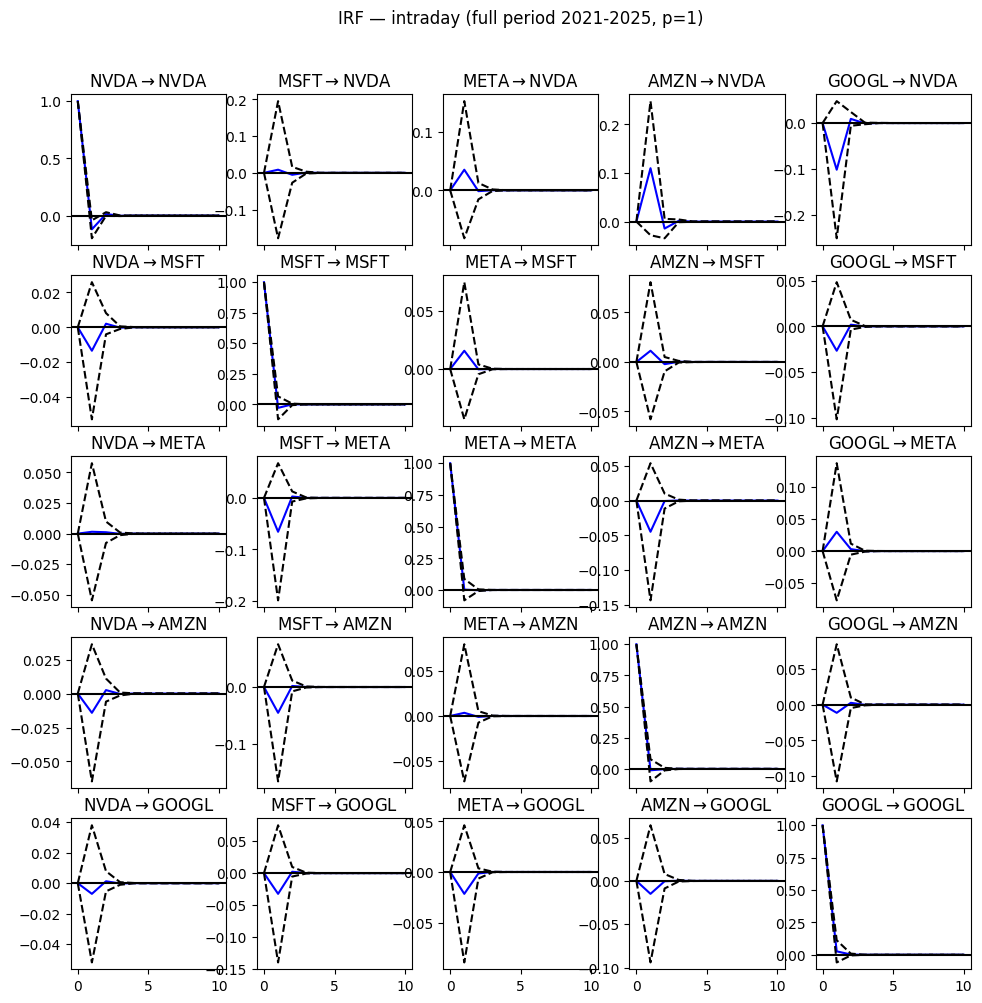

saved: output/irf_fullperiod_intraday.png


In [6]:
for name, (fitted, p) in fitted_full.items():
    irf = fitted.irf(periods=10)
    irf.plot(orth=False)
    plt.suptitle(f'IRF — {name} (full period 2021-2025, p={p})', y=1.01)
    out = f'output/irf_fullperiod_{name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'saved: {out}')